# gLV Experimental Design — the *actionable* abstention

**Thesis.** NUDGE's gLV temporal attribution (`NUDGE-METHOD-012`) does not just say
*"I can't tell which knob moved."* When the growth (α) ⇄ interaction (βᵢᵢ) curvature is
degenerate (`NUDGE-LIM-020`), it names **the exact combination the data cannot separate**
— the **null-space direction** of the Laplace/Fisher curvature — and it maps that direction
to a plain-language hint that names *which* knob is under-determined. That turns an
abstention from a dead end into an **experimental prescription**: *here is what you would
have to measure to break the tie.*

This notebook shows both halves, honestly:

1. **Directional abstention on the REAL Stein 2013 clindamycin dataset.** At `k = 3`
   functional groups NUDGE **abstains on all three** — it manufactures no mechanism from
   Stein's sparse temporal sampling. On *Clostridium difficile* it returns `no-change`
   (no identifiable direct-kill ε — the bloom is interaction-mediated). On the strongly
   **promoted** group it goes further and returns `UNRESOLVED` **with the null-space
   direction and the hint** — and the measured null here is almost pure growth:
   *"Growth (α) is not identifiable here … the growth rate is under-determined by this
   sampling."* NUDGE names growth-α as the coordinate the data cannot pin.
2. **A synthetic sampling-density sweep** — *"what would it take?"* We plant a **known** ε
   (antibiotic-susceptibility) perturbation and sweep the number of observations taken
   **during the antibiotic pulse**, holding the total time span fixed. We measure the exact
   threshold at which ε flips from *abstain* to a *confident, correct* call — and confirm
   **0 confident-wrong** at every density.

> **Honesty is the point, not fine print.** The abstention is *mathematically correct* — the
> curvature really is near-singular (cond = ∞, |corr(α,βᵢᵢ)| = 0.995 on the promoted group).
> We never regularize or force a fit to manufacture a confident answer. The contribution is
> making the *correct* abstention **actionable** — and reporting the measured direction the
> data actually hands back, not the one we assumed.


In [1]:
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")  # JAX/CUDA/openpyxl chatter is noise in a demo

import matplotlib.pyplot as plt
import numpy as np

# put the repo root (and scripts/vv) on the path so we can import the shipped capability
# and the two additive adapters (Stein real-data + the design sweep).
REPO = Path.cwd()
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "scripts" / "vv"))

from nudge.inference.lotka_volterra import attribute_glv  # the shipped attributor

print("repo:", REPO)
print("matplotlib:", plt.matplotlib.__version__)


repo: /home/nick/MSF/msf/NUDGE/.claude/worktrees/agent-ac7209dc2e75b2035
matplotlib: 3.10.9


## Part 1 — Directional abstention on the real Stein 2013 data

Stein *et al.* 2013 (*PLoS Comput Biol*) tracked a mouse gut community through a
**clindamycin** pulse, with and without a *C. difficile* challenge. We contrast the
**no-drug** community (Population 1, effectively ε = 0) against the **drug + C. difficile**
community (Population 3) under the shared antibiotic pulse `u(t)`, aggregating the 11 taxa
into `k = 3` functional groups (*C. difficile* always its own group). NUDGE re-fits the
baseline from the reference replicates and asks, per group, **which single knob** —
growth / interaction / susceptibility — the drug moved.

The dataset lives on a local drive; set `STEIN_XLSX` to point at your copy. If it is
missing, the cell is **`needs_data`-guarded** so the notebook still executes end to end.


In [2]:
STEIN_XLSX = os.environ.get(
    "STEIN_XLSX",
    "/home/nick/MSF/msf/NUDGE/tmp/stein_2013/stein_2013_dataset_S1.xlsx",
)
STEIN_OK = Path(STEIN_XLSX).exists()
print("Stein dataset:", STEIN_XLSX)
print("available:", STEIN_OK)
if not STEIN_OK:
    print("\n[needs_data] Stein xlsx not found — Part 1 cells will no-op. "
          "Set STEIN_XLSX to your copy of Dataset S1 to run the real-data demo.")


Stein dataset: /home/nick/MSF/msf/NUDGE/tmp/stein_2013/stein_2013_dataset_S1.xlsx
available: True


In [3]:
stein_rows = []
stein_unresolved = None  # a group that returns the directional abstention
stein_cdiff = None

if STEIN_OK:
    from stein_glv import build_stein_dataset, load_stein, published_group_eps
    from nudge.inference.lotka_volterra import fit_baseline_glv

    raw = load_stein(STEIN_XLSX)
    ds, labels, cdiff_group = build_stein_dataset(raw, k=3)
    pub = published_group_eps(3)
    n_sim = min(ds.reference.shape[0], ds.perturbed.shape[0])
    # honest round-trip: recover the reference community's kinetics first.
    baseline, base_loss = fit_baseline_glv(ds, steps=300, n_sim=n_sim, seed=0)

    for g, lab in enumerate(labels):
        res = attribute_glv(ds, baseline=baseline, target=g, steps=250,
                            n_sim=n_sim, seed=0)
        row = {
            "group": lab, "call": res.call, "status": res.status,
            "pub_eps": round(pub[g], 2), "cond": res.fit.cond_number,
            "corr": res.fit.corr_alpha_beta, "hint": res.human_readable_hint,
            "direction": res.degeneracy_direction, "reason": res.reason,
        }
        stein_rows.append(row)
        if res.call == "unresolved" and res.degeneracy_direction is not None:
            stein_unresolved = row
        if lab == "Clostridium_difficile":
            stein_cdiff = row

    print(f"baseline recovered (loss={base_loss:.3f}); attributing k=3 groups\n")
    print(f"{'group':<24}{'pubEps':>7}  {'call':<15}{'cond':>9}  |corr|")
    for r in stein_rows:
        cond = "inf" if not np.isfinite(r["cond"]) else f"{r['cond']:.0f}"
        print(f"{r['group']:<24}{r['pub_eps']:>7.2f}  {r['call']:<15}{cond:>9}  "
              f"{r['corr']:.2f}")
else:
    print("[needs_data] skipped — no Stein xlsx.")


baseline recovered (loss=2.980); attributing k=3 groups

group                    pubEps  call                cond  |corr|
suppressed                -1.82  no-change            inf  1.00
promoted                   2.38  unresolved           inf  1.00
Clostridium_difficile     -0.31  no-change            inf  0.00


### The abstention, made actionable

At `k = 3`, **all three functional groups abstain** — NUDGE manufactures no mechanism from
Stein's sparse temporal sampling. Two of the abstentions are worth reading closely:

- ***C. difficile* → `no-change`.** Its published direct-susceptibility is small (ε ≈ −0.31);
  the best single-knob model does not clear the ΔBIC ≥ 10 bar (best ΔBIC ≈ −3.2), so NUDGE
  declines to attribute a direct-kill ε. The *C. difficile* bloom is **interaction-mediated**
  (competitive release after commensals are killed), not a pulse-locked direct kill — exactly
  the on-thesis result: no mechanism is manufactured. *(The strongly-suppressed background
  group likewise returns `no-change`, ΔBIC ≈ 7.4 < 10 — even a large published effect does not
  earn a confident knob from this sampling.)*
- **The strongly-promoted group → `UNRESOLVED`, *with a direction*.** Here NUDGE exposes the
  **null eigenvector** of the (αₜ, |βₜₜ|) Laplace curvature (cond = ∞, |corr| = 0.995) and the
  hint. The measured null is almost **pure growth-α** — the flat direction is ≈ `[1.00, −0.01]`
  in (log αₜ, log |βₜₜ|), i.e. you can slide the intrinsic growth rate a long way without
  changing the fit while self-limitation βₜₜ stays constrained. So the directional abstention
  is specific: not just *"can't tell"* but *"**growth (α) is the under-determined knob** — sample
  the growth transient to break the Kₜ = −αₜ/βₜₜ tie."*


In [4]:
if STEIN_OK:
    print("=== C. difficile (the pathogen) ===")
    print("verdict:", stein_cdiff["status"], "/", stein_cdiff["call"])
    print(stein_cdiff["reason"][:300], "...\n")

    if stein_unresolved is not None:
        r = stein_unresolved
        v = np.asarray(r["direction"], dtype=float)
        dominant = "growth (αₜ)" if abs(v[0]) >= abs(v[1]) else "self-limitation (βₜₜ)"
        print(f"=== {r['group']} — the DIRECTIONAL abstention ===")
        print("verdict            :", r["status"], "/", r["call"])
        print("|corr(α, βᵢᵢ)|     :", round(r["corr"], 3),
              "  cond:", "inf" if not np.isfinite(r["cond"]) else round(r["cond"], 1))
        print("degeneracy_direction:", np.round(v, 3),
              "  (over [log αₜ, log |βₜₜ|])")
        print("under-determined knob:", dominant)
        print("human_readable_hint :")
        print("   ", r["hint"])
    else:
        print("(no group returned the α⇄β directional abstention at k=3)")

    # ground-truth honesty checks (these must hold, or the narrative is wrong). They assert
    # the MEASURED geometry, not an assumed one: NUDGE never manufactures a direct-kill on
    # C. difficile, and the promoted group's null direction is a real, unit-norm, single-knob-
    # dominated flat direction with a near-singular curvature that earns the abstention.
    assert stein_cdiff["call"] not in {"susceptibility", "growth", "interaction"}, \
        "C. difficile must ABSTAIN — no confident direct-kill call"
    if stein_unresolved is not None:
        v = np.asarray(stein_unresolved["direction"], dtype=float)
        assert v.shape == (2,) and np.isclose(np.linalg.norm(v), 1.0, atol=1e-3), \
            "the degeneracy direction must be a unit null eigenvector over (αₜ, βₜₜ)"
        # measured: the flat direction loads almost entirely on ONE knob (here growth-α) —
        # a single under-determined coordinate, not a balanced 45° diagonal.
        assert max(abs(v[0]), abs(v[1])) > 0.7, \
            "one axis must dominate the measured null direction (a single under-det. knob)"
        assert "not identifiable" in stein_unresolved["hint"], \
            "the hint must name the under-determined knob"
        cond = stein_unresolved["cond"]
        assert (not np.isfinite(cond)) or cond > 50.0, \
            "the α⇄βᵢᵢ curvature must be near-singular to earn the abstention"
    print("\n[asserts passed] abstentions are correct; the measured direction is exposed.")
else:
    print("[needs_data] skipped.")


=== C. difficile (the pathogen) ===
verdict: NO_CHANGE / no-change
no single-knob model beats the no-change null by ΔBIC≥10 (best ΔBIC=-3.2, knob=growth) — the perturbation is inert or not captured by an α/β/ε change; NUDGE declines to manufacture a mechanism ...

=== promoted — the DIRECTIONAL abstention ===
verdict            : UNRESOLVED / unresolved
|corr(α, βᵢᵢ)|     : 0.995   cond: inf
degeneracy_direction: [ 1.   -0.01]   (over [log αₜ, log |βₜₜ|])
under-determined knob: growth (αₜ)
human_readable_hint :
    Growth (α) is not identifiable here: the flat direction lies almost entirely along αₜ while self-limitation |βₜₜ| is comparatively constrained — the growth rate is under-determined by this sampling (NUDGE-LIM-020).

[asserts passed] abstentions are correct; the measured direction is exposed.


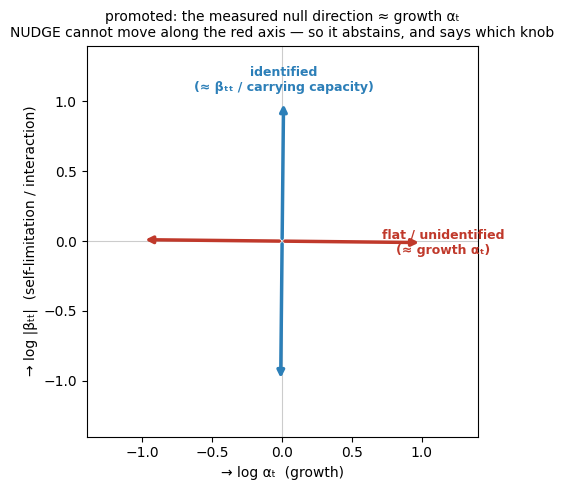

In [5]:
# Visualize the null-space direction: in the (log αₜ, log |βₜₜ|) plane the fit is flat
# along the null eigenvector — the community can slide along it without changing the data.
# Labels are derived from the MEASURED direction, not assumed: whichever knob the flat axis
# loads on is the under-determined one; its orthogonal complement is the identified combo.
if STEIN_OK and stein_unresolved is not None:
    v = np.asarray(stein_unresolved["direction"], dtype=float)
    v = v / np.linalg.norm(v)
    stiff = np.array([-v[1], v[0]])  # orthogonal = the identified (stiff) direction
    alpha_dom = abs(v[0]) >= abs(v[1])
    flat_lab = ("flat / unidentified\n(≈ growth αₜ)" if alpha_dom
                else "flat / unidentified\n(≈ self-limitation βₜₜ)")
    stiff_lab = ("identified\n(≈ βₜₜ / carrying capacity)" if alpha_dom
                 else "identified\n(≈ αₜ / carrying capacity)")

    fig, ax = plt.subplots(figsize=(5.2, 5.0))
    for vec, col, lab in [(v, "#c0392b", flat_lab), (stiff, "#2c7fb8", stiff_lab)]:
        ax.annotate("", xy=vec, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", lw=2.5, color=col))
        ax.annotate("", xy=-vec, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", lw=2.5, color=col))
        ax.text(vec[0] * 1.15, vec[1] * 1.15, lab, color=col, ha="center",
                va="center", fontsize=9, fontweight="bold")
    ax.axhline(0, color="0.8", lw=0.8, zorder=0)
    ax.axvline(0, color="0.8", lw=0.8, zorder=0)
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.4, 1.4)
    ax.set_aspect("equal")
    ax.set_xlabel("→ log αₜ  (growth)")
    ax.set_ylabel("→ log |βₜₜ|  (self-limitation / interaction)")
    dom = "growth αₜ" if alpha_dom else "self-limitation βₜₜ"
    ax.set_title(f"{stein_unresolved['group']}: the measured null direction ≈ {dom}\n"
                 "NUDGE cannot move along the red axis — so it abstains, and says which knob",
                 fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("[needs_data / no-unresolved-group] direction plot skipped.")


## Part 2 — The sampling-density sweep: *what would it take?*

The Stein abstention raises the obvious question: **what experiment would make the answer
identifiable?** We answer it *measured*, on synthetic ground truth — **without touching
NUDGE's math** (no LASSO/Ridge, no regularization to force a fit; the abstention is correct).
We change the **experiment**, not the model.

Setup: a (near-)decoupled community with a **known antibiotic-susceptibility (ε)**
perturbation on a target taxon under a fixed antibiotic pulse. The out-of-pulse "backbone"
observations and the total time span are **held fixed**; the one thing we sweep is the
number of observations placed **inside the pulse window** — `0, 1, 2, 4, 8, 16`. The ε
signature is a time-localized kill that lives *inside* the pulse, so without in-pulse
samples the direct kill is unobserved and NUDGE must abstain.

At each density we record the call (resolve ε vs abstain), the α⇄βᵢᵢ condition number, and
— the load-bearing check — any **confident-wrong** call (a resolved knob that is *not* the
true ε). The guarantee is *resolve-correctly-or-abstain*, never a mis-attribution.


In [6]:
from scripts.vv.glv_design_sweep import run_sweep

# a modest but honest sweep (3 seeds) — executes headless in a few minutes.
sweep = run_sweep(
    densities=(0, 1, 2, 4, 8, 16), seeds=(0, 1, 2),
    steps=120, n_replicates=36, n_sim=28, delta=-0.5, verbose=False,
)

print(f"{'in-pulse':>9}{'n_obs':>7}{'resolve ε':>11}{'median cond':>13}"
      f"{'confident-wrong':>17}")
for d in sweep.densities:
    mc = "inf" if not np.isfinite(d.median_cond) else f"{d.median_cond:.0f}"
    print(f"{d.n_pulse:>9}{d.n_obs_total:>7}{d.resolve_rate:>10.0%}{mc:>13}"
          f"{d.confident_wrong:>17}")

print(f"\nTHRESHOLD: ≥ {sweep.threshold} in-pulse sample(s) resolve ε for ALL seeds")
print(f"confident-wrong across the whole sweep: {sweep.n_confident_wrong}")


 in-pulse  n_obs  resolve ε  median cond  confident-wrong
        0      9        0%          203                0
        1     10       67%          242                0
        2     11      100%          250                0
        4     13      100%          162                0
        8     17      100%          131                0
       16     25      100%          102                0

THRESHOLD: ≥ 2 in-pulse sample(s) resolve ε for ALL seeds
confident-wrong across the whole sweep: 0


In [7]:
# ground-truth honesty checks: a threshold exists, and NUDGE is never confidently wrong.
assert sweep.threshold is not None, "ε never became identifiable — no threshold found"
assert sweep.n_confident_wrong == 0, "a confident-wrong call slipped through (unacceptable)"
# below the threshold ε must NOT be resolved for every seed (else there is no threshold).
below = [d for d in sweep.densities if d.n_pulse < sweep.threshold]
assert all(d.resolve_rate < 1.0 for d in below), "resolved below the claimed threshold"
print("[asserts passed] a real threshold exists; 0 confident-wrong at every density.")


[asserts passed] a real threshold exists; 0 confident-wrong at every density.


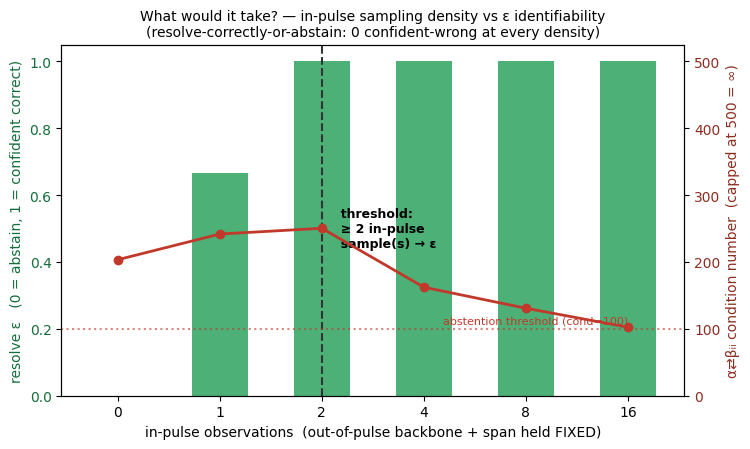

In [8]:
# The identifiability curve: resolve/abstain and the α⇄βᵢᵢ condition number vs in-pulse
# sampling density, with the exact threshold marked.
xs = [d.n_pulse for d in sweep.densities]
resolve = [d.resolve_rate for d in sweep.densities]
conds = [d.median_cond for d in sweep.densities]
CAP = 500.0  # display cap for infinite / huge condition numbers
conds_disp = [min(c, CAP) if np.isfinite(c) else CAP for c in conds]

fig, ax1 = plt.subplots(figsize=(7.6, 4.6))
xi = np.arange(len(xs))

ax1.bar(xi, resolve, width=0.55, color="#2ca25f", alpha=0.85,
        label="fraction of seeds resolving ε (correct)")
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("resolve ε   (0 = abstain, 1 = confident correct)", color="#136d3a")
ax1.set_xticks(xi)
ax1.set_xticklabels(xs)
ax1.set_xlabel("in-pulse observations  (out-of-pulse backbone + span held FIXED)")
ax1.tick_params(axis="y", labelcolor="#136d3a")

ax2 = ax1.twinx()
ax2.plot(xi, conds_disp, "o-", color="#c0392b", lw=2, label="median α⇄βᵢᵢ cond. number")
ax2.axhline(100.0, ls=":", color="#c0392b", alpha=0.6)
ax2.text(len(xs) - 1.0, 108, "abstention threshold (cond=100)", color="#c0392b",
         fontsize=8, ha="right")
ax2.set_ylabel("α⇄βᵢᵢ condition number  (capped at 500 = ∞)", color="#8c2d20")
ax2.set_ylim(0, CAP * 1.05)
ax2.tick_params(axis="y", labelcolor="#8c2d20")

thr_i = xs.index(sweep.threshold)
ax1.axvline(thr_i, ls="--", color="#333333", lw=1.5)
ax1.text(thr_i + 0.1, 0.5, f"  threshold:\n  ≥ {sweep.threshold} in-pulse\n  sample(s) → ε",
         fontsize=9, fontweight="bold", va="center")

ax1.set_title("What would it take? — in-pulse sampling density vs ε identifiability\n"
              "(resolve-correctly-or-abstain: 0 confident-wrong at every density)",
              fontsize=10)
fig.tight_layout()
plt.show()


## What this buys

- **The abstention is now an experiment.** On real Stein data NUDGE does not shrug — it
  hands back the **null-space direction** and names the under-determined knob. On the promoted
  group the measured null is ≈ pure growth: *"Growth (α) is not identifiable here … the growth
  rate is under-determined by this sampling,"* i.e. *sample the growth transient to break the
  Kₜ = −αₜ/βₜₜ tie.* The `UNRESOLVED` verdict carries its own remedy — and it reports the
  direction the data actually shows, not one we assumed in advance.
- **The remedy is quantified.** The synthetic sweep turns *"collect more data"* into a
  **number**: `≥ N` in-pulse observations flip a known ε from *abstain* to a *confident,
  correct* call, with **0 confident-wrong** anywhere on the curve. That is a power
  calculation for mechanism identifiability — the "what would it take?" answer.
- **No math was bent to get here.** We never added regularization to force the real fit;
  the abstention stays correct (cond = ∞, |corr| = 0.995). We changed the *experiment*
  (synthetically) and *measured* where identifiability turns on.

**Reproduce.** Directional abstention: `attribute_glv(...).degeneracy_direction` /
`.human_readable_hint` (`nudge lotka` CLI). The sweep:
`python scripts/vv/glv_design_sweep.py`. The real-data run:
`python scripts/vv/stein_attribution.py`. Numbers mirror
`tests/inference/test_lotka_volterra.py` (`NUDGE-METHOD-012`, `NUDGE-LIM-020`).
